# Jefferies PnL, reduce markouts

## Data Prep

In [74]:
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt

In [4]:
raw = pd.read_excel('RFQ US Rates - Bonds Only (July - Sept 24) - Blockhouse.xlsx')
raw

,EventDate,Id,Client,RFQStatus,InstrumentSubGroup,Mkt Traded Vol,Market Traded Vol (USD),Our Traded Vol,Our Traded Vol (USD),TiedWonVol,...,SettlementDays,SettlementDate,SettlementStops,RFQ CreateTime,RFQ ClosedTime,AnAutoReplyRFQs,First Response Time (Sec),TradeSizeBucket,Sector,MaturityBucket
0,2024-09-30,66FA7D45432800D20002,Client8,Done,OFFTHERUN,100000000,100000000,100000000,100000000,100000000,...,1,2024-10-01,T+1,2024-09-30 06:28:00,2024-09-30 06:28:00,1,0.03,50+M,5-7 YR,5y-7y
1,2024-09-30,TRSY_20240930_15961,Client9,Done,"OFFTHERUN,DOUBLEOLDS",2100000,2100000,2100000,2100000,2100000,...,1,2024-10-01,T+1,2024-09-30 16:00:00,2024-09-30 16:00:00,1,0.95,1-5M,7-10 YR,7y-10y
2,2024-09-30,TRSY_20240930_314,Client9,Done,ONTHERUN,53000000,53000000,53000000,53000000,53000000,...,1,2024-10-01,T+1,2024-09-30 15:46:00,2024-09-30 15:46:00,1,0.07,50+M,7-10 YR,7y-10y
3,2024-09-30,66FAEA57432800020001,Client41,Done,OFFTHERUN,500000,500000,500000,500000,500000,...,1,2024-10-01,T+1,2024-09-30 14:14:00,2024-09-30 14:14:00,1,0.03,500K-1M,0-1 YR,<18mos
4,2024-09-30,66FAC35D455C00210006,Client139,Done,OFFTHERUN,1058000,1058000,1058000,1058000,1058000,...,1,2024-10-01,T+1,2024-09-30 11:27:00,2024-09-30 11:27:00,1,0.03,1-5M,5-7 YR,3y-5y
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
40825,2024-07-01,E682EBF3454C00010001,Client736,CustomerTimeOut,OFFTHERUN,0,0,0,0,0,...,1,2024-07-02,T+1,2024-07-01 13:48:00,2024-07-01 13:50:00,1,0.03,10-25M,5-7 YR,3y-5y
40826,2024-07-01,E682D1C745CC000A0001,Client736,CustomerTimeOut,OFFTHERUN,0,0,0,0,0,...,1,2024-07-02,T+1,2024-07-01 11:56:00,2024-07-01 11:58:00,1,0.06,25-50M,5-7 YR,3y-5y
40827,2024-07-01,E682C785454C00010001,Client736,CustomerTimeOut,OFFTHERUN,0,0,0,0,0,...,1,2024-07-02,T+1,2024-07-01 11:13:00,2024-07-01 11:14:00,1,0.03,25-50M,5-7 YR,3y-5y
40828,2024-07-01,E682AFF2454C000C0001,Client736,CustomerTimeOut,"OFFTHERUN,DOUBLEOLDS",0,0,0,0,0,...,1,2024-07-02,T+1,2024-07-01 09:32:00,2024-07-01 09:34:00,1,0.04,10-25M,5-7 YR,3y-5y


In [5]:
raw.columns

Index(['EventDate', 'Id', 'Client', 'RFQStatus', 'InstrumentSubGroup',
       'Mkt Traded Vol', 'Market Traded Vol (USD)', 'Our Traded Vol',
       'Our Traded Vol (USD)', 'TiedWonVol', 'Num of Dealers', 'Trader',
       'Sales', 'Covered Vol', 'ActionStr', 'Tier', 'InstrumentCode',
       'InstrumentDescription', 'AssetClass', 'Market', 'LegNo',
       'Maturity Date', 'RFQNumberOfQuotes', 'Buy/Sell', 'Best Bid Price',
       'Mid Price', 'Best Ask Price', 'Deal Value', 'AwayFromMid',
       'TickIdentifier', 'Deal Spread', 'Cover', 'CoverPnL', 'SettlementDays',
       'SettlementDate', 'SettlementStops', 'RFQ CreateTime', 'RFQ ClosedTime',
       'AnAutoReplyRFQs', 'First Response Time (Sec)', 'TradeSizeBucket',
       'Sector', 'MaturityBucket'],
      dtype='object')

In [8]:
raw.InstrumentCode.value_counts()

InstrumentCode
91282CLF6    4144
91282CKQ3    3398
912810UA4    2143
91282CLC3    1556
912810UC0    1445
             ... 
912810FE3       5
912810EX2       5
912810EZ7       5
912810FF0       5
912810EY0       5
Name: count, Length: 363, dtype: int64

There are 363 different instruments being traded in the dataset.

In [4]:
raw['ActionStr'].value_counts()

ActionStr
TradedAway           22617
Covered               6658
CustRejectedQuote     3406
Expired               2400
TiedTradedAway        2161
CustAcceptedQuote     1491
DealerAcceptOrder     1364
CoverTied              659
DealerReject            74
Name: count, dtype: int64

In [5]:
raw.Tier.value_counts()

Tier
TIER2           28354
TIER1            5004
MANUAL           3337
TierINTERNAL     2827
TIER9             793
TierGOLD          302
TIER3             182
UNKNOWN            31
Name: count, dtype: int64

In [108]:
raw.MaturityBucket.value_counts()

MaturityBucket
10-30y    10499
<18mos     8457
7y-10y     8065
3y-5y      6827
5y-7y      2747
18m-2y     2218
2y-3y      2017
Name: count, dtype: int64

In [20]:
valid_tiers = ['TIER1', 'TIER2', 'TIER3', 'TIER9', 'TierGOLD', 'TierINTERNAL', 'MANUAL']

# Apply filters
df = raw[
    (raw['Our Traded Vol'] != 0) & 
    (raw['Tier'].isin(valid_tiers))
].copy()

# view = ['EventDate','Market Traded Vol (USD)','Our Traded Vol (USD)','Tier','Buy/Sell','Best Bid Price','Best Ask Price','Mid Price','Deal Value','Deal Spread','Cover','CoverPnL','Sector']
df

,EventDate,Id,Client,RFQStatus,InstrumentSubGroup,Mkt Traded Vol,Market Traded Vol (USD),Our Traded Vol,Our Traded Vol (USD),TiedWonVol,...,SettlementDays,SettlementDate,SettlementStops,RFQ CreateTime,RFQ ClosedTime,AnAutoReplyRFQs,First Response Time (Sec),TradeSizeBucket,Sector,MaturityBucket
0,2024-09-30,66FA7D45432800D20002,Client8,Done,OFFTHERUN,100000000,100000000,100000000,100000000,100000000,...,1,2024-10-01,T+1,2024-09-30 06:28:00,2024-09-30 06:28:00,1,0.03,50+M,5-7 YR,5y-7y
1,2024-09-30,TRSY_20240930_15961,Client9,Done,"OFFTHERUN,DOUBLEOLDS",2100000,2100000,2100000,2100000,2100000,...,1,2024-10-01,T+1,2024-09-30 16:00:00,2024-09-30 16:00:00,1,0.95,1-5M,7-10 YR,7y-10y
2,2024-09-30,TRSY_20240930_314,Client9,Done,ONTHERUN,53000000,53000000,53000000,53000000,53000000,...,1,2024-10-01,T+1,2024-09-30 15:46:00,2024-09-30 15:46:00,1,0.07,50+M,7-10 YR,7y-10y
3,2024-09-30,66FAEA57432800020001,Client41,Done,OFFTHERUN,500000,500000,500000,500000,500000,...,1,2024-10-01,T+1,2024-09-30 14:14:00,2024-09-30 14:14:00,1,0.03,500K-1M,0-1 YR,<18mos
4,2024-09-30,66FAC35D455C00210006,Client139,Done,OFFTHERUN,1058000,1058000,1058000,1058000,1058000,...,1,2024-10-01,T+1,2024-09-30 11:27:00,2024-09-30 11:27:00,1,0.03,1-5M,5-7 YR,3y-5y
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
40073,2024-07-01,E682C6A157D0001B0001,Client736,Done,ONTHERUN,1000000,1000000,1000000,1000000,0,...,1,2024-07-02,T+1,2024-07-01 11:09:00,2024-07-01 11:09:00,1,0.04,1-5M,5-7 YR,3y-5y
40074,2024-07-01,TRSY_20240701_9910,Client775,Done,"OFFTHERUN,OLDBONDS",3660000,3660000,3660000,3660000,0,...,1,2024-07-02,T+1,2024-07-01 15:57:00,2024-07-01 15:57:00,0,0.07,1-5M,15-30 YR,10-30y
40075,2024-07-01,TRSY_20240701_5800,Client775,Done,ONTHERUN,9630000,9630000,9630000,9630000,0,...,1,2024-07-02,T+1,2024-07-01 13:15:00,2024-07-01 13:15:00,0,0.06,5-10M,7-10 YR,7y-10y
40076,2024-07-01,TRSY_20240701_9909,Client775,Done,ONTHERUN,2300000,2300000,2300000,2300000,0,...,1,2024-07-02,T+1,2024-07-01 11:58:00,2024-07-01 11:58:00,0,0.06,1-5M,15-30 YR,10-30y


In [21]:
df.Tier.value_counts()

Tier
TIER2           1698
TierINTERNAL     723
TIER1            212
TierGOLD         104
TIER9             46
TIER3             35
MANUAL            33
Name: count, dtype: int64

## PnL for bid ask spread (no inventory control)

Gain of single trade
$$ G_{T} = v_0 \epsilon_{t} \left(m_{t} + \epsilon_{t} \frac{S_{t}}{2} - m_{T} \right)  $$


Expected gain of market-maker between time $0$ and $T$

$$ \mathbb{E}[G_T] = v_0 \left( \sum_{t=0}^{T-1} \mathbb{E} \left[ \theta_t \varepsilon_t \left( m_t + \varepsilon_t \frac{S_t}{2} - m_T \right) + \theta_t \omega \right] \right) $$

where $G_{T}$ is gain at time $T$,

$v_{0}$ is volume,

$S_{t}$ is the spread

$\epsilon$ is order sign,

$m_{t}$ is mid-price at time $t$,

$\theta_t$ is execution indicator,

$\omega$ is additional payment

We assume that there are no additional payments like processing or transaction costs. We also assume that every trade is executed. Therefore, $\theta = 1$ and $\omega = 0$

$$ \mathbb{E}[G_T] = v_0 \left( \sum_{t=0}^{T-1} \mathbb{E} \left[\varepsilon_t \left( m_t + \varepsilon_t \frac{S_{t}}{2} - m_{T} \right) \right] \right) $$

In [22]:
df['Sign'] = df['Buy/Sell'].apply(lambda x: 1 if x == 'Buy' else -1)
df['Sign'].value_counts()

Sign
-1    1557
 1    1294
Name: count, dtype: int64

In [23]:
def pnl(df):
    df_calc = df.copy() 
    # Calculate spread
    df_calc['spread'] = ((df_calc['Best Ask Price'] - df_calc['Best Bid Price'])/df_calc['Deal Value']) * 10000
    
    # Calculate PnL per trade using the formula
    df_calc['PnL'] = (
        df_calc['Our Traded Vol (USD)'] *  # v_0
        df_calc['Sign'] * (             # ε_t
            df_calc['Mid Price'] +         # m_t
            df_calc['Sign'] * ((df_calc['spread'] / 2) * df_calc['Deal Value'] / 10000) - # ε_t * S_t/2
            df_calc['Mid Price']           # m_T (same as m_t for individual trades)
        )
    )
    
    return df_calc

In [24]:
result1 = pnl(df)
result1

,EventDate,Id,Client,RFQStatus,InstrumentSubGroup,Mkt Traded Vol,Market Traded Vol (USD),Our Traded Vol,Our Traded Vol (USD),TiedWonVol,...,RFQ CreateTime,RFQ ClosedTime,AnAutoReplyRFQs,First Response Time (Sec),TradeSizeBucket,Sector,MaturityBucket,Sign,spread,PnL
0,2024-09-30,66FA7D45432800D20002,Client8,Done,OFFTHERUN,100000000,100000000,100000000,100000000,100000000,...,2024-09-30 06:28:00,2024-09-30 06:28:00,1,0.03,50+M,5-7 YR,5y-7y,-1,2.354141,1.171875e+06
1,2024-09-30,TRSY_20240930_15961,Client9,Done,"OFFTHERUN,DOUBLEOLDS",2100000,2100000,2100000,2100000,2100000,...,2024-09-30 16:00:00,2024-09-30 16:00:00,1,0.95,1-5M,7-10 YR,7y-10y,-1,2.303971,2.460938e+04
2,2024-09-30,TRSY_20240930_314,Client9,Done,ONTHERUN,53000000,53000000,53000000,53000000,53000000,...,2024-09-30 15:46:00,2024-09-30 15:46:00,1,0.07,50+M,7-10 YR,7y-10y,-1,0.783116,2.070312e+05
3,2024-09-30,66FAEA57432800020001,Client41,Done,OFFTHERUN,500000,500000,500000,500000,500000,...,2024-09-30 14:14:00,2024-09-30 14:14:00,1,0.03,500K-1M,0-1 YR,<18mos,-1,0.784745,1.953125e+03
4,2024-09-30,66FAC35D455C00210006,Client139,Done,OFFTHERUN,1058000,1058000,1058000,1058000,1058000,...,2024-09-30 11:27:00,2024-09-30 11:27:00,1,0.03,1-5M,5-7 YR,3y-5y,1,1.537811,8.265625e+03
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
40073,2024-07-01,E682C6A157D0001B0001,Client736,Done,ONTHERUN,1000000,1000000,1000000,1000000,0,...,2024-07-01 11:09:00,2024-07-01 11:09:00,1,0.04,1-5M,5-7 YR,3y-5y,1,0.787991,3.906250e+03
40074,2024-07-01,TRSY_20240701_9910,Client775,Done,"OFFTHERUN,OLDBONDS",3660000,3660000,3660000,3660000,0,...,2024-07-01 15:57:00,2024-07-01 15:57:00,0,0.07,1-5M,15-30 YR,10-30y,-1,3.337784,5.718750e+04
40075,2024-07-01,TRSY_20240701_5800,Client775,Done,ONTHERUN,9630000,9630000,9630000,9630000,0,...,2024-07-01 13:15:00,2024-07-01 13:15:00,0,0.06,5-10M,7-10 YR,7y-10y,-1,0.787774,3.761719e+04
40076,2024-07-01,TRSY_20240701_9909,Client775,Done,ONTHERUN,2300000,2300000,2300000,2300000,0,...,2024-07-01 11:58:00,2024-07-01 11:58:00,0,0.06,1-5M,15-30 YR,10-30y,-1,1.191233,1.347656e+04


## Adjust spread
- define optimal spread
- calculate volume changes
- calculate according pnl

### tier 1, sample

In [63]:
t1 = result1[result1['Tier'] == 'TIER1']

In [65]:
t1.spread.describe()

count    212.000000
mean       1.568069
std        3.092379
min        0.000000
25%        0.391650
50%        0.794520
75%        1.944329
max       42.698548
Name: spread, dtype: float64

In [70]:
# Optimal spread table
optimal_t1_spread = {
    '<18mos': 0.66,
    '18m-2y': 3.04,
    '2y-3y': 3.50,
    '3y-5y': 3.27,
    '5y-7y': 4.24,
    '7y-10y': 5.46,
    '10-30y': 2.00
}

# Map the optimal spread to the dataset
t1['Optimal_Spread'] = t1['MaturityBucket'].map(optimal_t1_spread)

C:\Users\ysnow\AppData\Local\Temp\ipykernel_11452\778451421.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  t1['Optimal_Spread'] = t1['MaturityBucket'].map(optimal_t1_spread)


In [73]:
t1.head(2)

,EventDate,Id,Client,RFQStatus,InstrumentSubGroup,Mkt Traded Vol,Market Traded Vol (USD),Our Traded Vol,Our Traded Vol (USD),TiedWonVol,...,RFQ ClosedTime,AnAutoReplyRFQs,First Response Time (Sec),TradeSizeBucket,Sector,MaturityBucket,Sign,spread,PnL,Optimal_Spread
0,2024-09-30,66FA7D45432800D20002,Client8,Done,OFFTHERUN,100000000,100000000,100000000,100000000,100000000,...,2024-09-30 06:28:00,1,0.03,50+M,5-7 YR,5y-7y,-1,2.354141,1171875.000,4.24
1,2024-09-30,TRSY_20240930_15961,Client9,Done,"OFFTHERUN,DOUBLEOLDS",2100000,2100000,2100000,2100000,2100000,...,2024-09-30 16:00:00,1,0.95,1-5M,7-10 YR,7y-10y,-1,2.303971,24609.375,5.46


In [75]:
test3 = t1[t1['MaturityBucket']=='5y-7y']
test3.head(2)

,EventDate,Id,Client,RFQStatus,InstrumentSubGroup,Mkt Traded Vol,Market Traded Vol (USD),Our Traded Vol,Our Traded Vol (USD),TiedWonVol,...,RFQ ClosedTime,AnAutoReplyRFQs,First Response Time (Sec),TradeSizeBucket,Sector,MaturityBucket,Sign,spread,PnL,Optimal_Spread
0,2024-09-30,66FA7D45432800D20002,Client8,Done,OFFTHERUN,100000000,100000000,100000000,100000000,100000000,...,2024-09-30 06:28:00,1,0.03,50+M,5-7 YR,5y-7y,-1,2.354141,1171875.000,4.24
960,2024-09-27,66F6E619432800000006,Client38,Done,OFFTHERUN,25300000,25300000,25300000,25300000,25300000,...,2024-09-27 13:06:00,1,0.03,25-50M,7-10 YR,5y-7y,-1,0.752276,98828.125,4.24


In [85]:
test3['status'] = test3.apply(lambda row: 'keep' if row['spread']*2 > row['Optimal_Spread'] else 'cancel', axis=1)

C:\Users\ysnow\AppData\Local\Temp\ipykernel_11452\534037092.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test3['status'] = test3.apply(lambda row: 'keep' if row['spread']*2 > row['Optimal_Spread'] else 'cancel', axis=1)


In [86]:
test3.status.value_counts()

status
cancel    24
keep      12
Name: count, dtype: int64

In [87]:
test3[['Client','spread','Optimal_Spread']]

,Client,spread,Optimal_Spread
0,Client8,2.354141,4.24
960,Client38,0.752276,4.24
980,Client603,2.322970,4.24
981,Client603,0.775795,4.24
1588,Client8,3.139594,4.24
1629,Client780,1.477978,4.24
3004,Client603,3.872517,4.24
3663,Client8,0.775705,4.24
3688,Client603,2.918111,4.24
3705,Client780,2.956502,4.24


### all table

In [25]:
# chao's original off, will be replaced by a table
optimal_spread_data_off = {
    'MaturityBucket': ['<18mos', '18m-2y', '2y-3y', '3y-5y', '5y-7y', '7y-10y', '10-30y'],
    'TIER1': [0.66, 3.04, 3.50, 3.27, 4.24, 5.46, 2.00],
    'TIER2': [0.74, 3.03, 2.85, 2.36, 3.26, 1.28, 0.75],
    'TIER3': [0.00, 0.00, 0.00, 0.00, 0.00, 0.00, 0.00],
    'TIER9': [0.63, 0.89, 1.71, 0.33, 3.66, 0.98, 3.20],
    'TierGOLD': [0.00, 0.00, 0.00, 0.00, 0.00, 0.00, 0.00],
    'TierINTERNAL': [0.00, 0.00, 0.00, 0.00, 0.00, 0.00, 0.00],
    'MANUAL': [0.94, 3.12, 2.69, 2.42, 5.71, 5.25, 0.19]
}

optimal_spread_df_off = pd.DataFrame(optimal_spread_data_off)

# Melt the optimal spread table for easier merging
optimal_spread_melted_off = optimal_spread_df_off.melt(
    id_vars=['MaturityBucket'], 
    var_name='Tier', 
    value_name='Optimal_Spread'
)

# Merge the datasets on Tier and Maturity_Bucket
df_optimal = result1.merge(optimal_spread_melted_off, on=['Tier', 'MaturityBucket'], how='left')

In [27]:
df_optimal

,EventDate,Id,Client,RFQStatus,InstrumentSubGroup,Mkt Traded Vol,Market Traded Vol (USD),Our Traded Vol,Our Traded Vol (USD),TiedWonVol,...,RFQ ClosedTime,AnAutoReplyRFQs,First Response Time (Sec),TradeSizeBucket,Sector,MaturityBucket,Sign,spread,PnL,Optimal_Spread
0,2024-09-30,66FA7D45432800D20002,Client8,Done,OFFTHERUN,100000000,100000000,100000000,100000000,100000000,...,2024-09-30 06:28:00,1,0.03,50+M,5-7 YR,5y-7y,-1,2.354141,1.171875e+06,4.24
1,2024-09-30,TRSY_20240930_15961,Client9,Done,"OFFTHERUN,DOUBLEOLDS",2100000,2100000,2100000,2100000,2100000,...,2024-09-30 16:00:00,1,0.95,1-5M,7-10 YR,7y-10y,-1,2.303971,2.460938e+04,5.46
2,2024-09-30,TRSY_20240930_314,Client9,Done,ONTHERUN,53000000,53000000,53000000,53000000,53000000,...,2024-09-30 15:46:00,1,0.07,50+M,7-10 YR,7y-10y,-1,0.783116,2.070312e+05,5.46
3,2024-09-30,66FAEA57432800020001,Client41,Done,OFFTHERUN,500000,500000,500000,500000,500000,...,2024-09-30 14:14:00,1,0.03,500K-1M,0-1 YR,<18mos,-1,0.784745,1.953125e+03,0.74
4,2024-09-30,66FAC35D455C00210006,Client139,Done,OFFTHERUN,1058000,1058000,1058000,1058000,1058000,...,2024-09-30 11:27:00,1,0.03,1-5M,5-7 YR,3y-5y,1,1.537811,8.265625e+03,2.36
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2846,2024-07-01,E682C6A157D0001B0001,Client736,Done,ONTHERUN,1000000,1000000,1000000,1000000,0,...,2024-07-01 11:09:00,1,0.04,1-5M,5-7 YR,3y-5y,1,0.787991,3.906250e+03,2.36
2847,2024-07-01,TRSY_20240701_9910,Client775,Done,"OFFTHERUN,OLDBONDS",3660000,3660000,3660000,3660000,0,...,2024-07-01 15:57:00,0,0.07,1-5M,15-30 YR,10-30y,-1,3.337784,5.718750e+04,0.75
2848,2024-07-01,TRSY_20240701_5800,Client775,Done,ONTHERUN,9630000,9630000,9630000,9630000,0,...,2024-07-01 13:15:00,0,0.06,5-10M,7-10 YR,7y-10y,-1,0.787774,3.761719e+04,1.28
2849,2024-07-01,TRSY_20240701_9909,Client775,Done,ONTHERUN,2300000,2300000,2300000,2300000,0,...,2024-07-01 11:58:00,0,0.06,1-5M,15-30 YR,10-30y,-1,1.191233,1.347656e+04,0.75


we accept clients who are willing to pay x times of current spread

In [33]:
df_optimal['status'] = df_optimal.apply(lambda row: 'keep' if row['spread']*1.5 > row['Optimal_Spread'] else 'cancel', axis=1)

In [34]:
df_optimal.status.value_counts()

status
keep      1693
cancel    1158
Name: count, dtype: int64

In [23]:
def pnl_optimal(df):
    # Create a copy of the dataframe
    df_calc = df.copy()
    
    # Initialize optimal_PnL column with zeros
    df_calc['optimal_PnL'] = 0
    
    # Calculate optimal_PnL only for non-cancelled trades
    non_cancelled_mask = df_calc['status'] != 'cancel'
    df_calc.loc[non_cancelled_mask, 'optimal_PnL'] = (
        df_calc['Our Traded Vol (USD)'] *
        df_calc['Sign'] *
        (
            df_calc['Mid Price'] +
            df_calc['Sign'] *
            (
                ((df_calc['Optimal_Spread'] / 2) * df_calc['Deal Value'] / 10000)
            ) -
            df_calc['Mid Price']
        )
    )
    
    # Initialize saving column with zeros
    df_calc['saving'] = 0
    
    # Calculate saving only for non-cancelled trades
    # Note: This uses the existing PnL column without modifying it
    df_calc.loc[non_cancelled_mask, 'saving'] = (
        df_calc.loc[non_cancelled_mask, 'optimal_PnL'] - 
        df_calc.loc[non_cancelled_mask, 'PnL']
    )
    
    return df_calc

In [35]:
def helper(df):
    # Create a copy of the input DataFrame
    df_calc = df.copy()
    
    # Initialize PnL columns
    df_calc['optimal_PnL'] = 0
    
    # Create masks for different spread conditions
    spread_greater = (df_calc['spread'] > df_calc['Optimal_Spread']) & (df_calc['status'] != 'cancel')
    spread_lesser = (df_calc['spread'] <= df_calc['Optimal_Spread']) & (df_calc['status'] != 'cancel')
    
    # Calculate optimal PnL when spread > optimal_spread (use spread)
    df_calc.loc[spread_greater, 'optimal_PnL'] = (
        df_calc.loc[spread_greater, 'Our Traded Vol (USD)'] *
        df_calc.loc[spread_greater, 'Sign'] * (
            df_calc.loc[spread_greater, 'Mid Price'] +
            df_calc.loc[spread_greater, 'Sign'] *
            ((df_calc.loc[spread_greater, 'spread'] / 2) * 
             df_calc.loc[spread_greater, 'Deal Value'] / 10000) -
            df_calc.loc[spread_greater, 'Mid Price']
        )
    )
    
    # Calculate optimal PnL when spread <= optimal_spread (use optimal_spread)
    df_calc.loc[spread_lesser, 'optimal_PnL'] = (
        df_calc.loc[spread_lesser, 'Our Traded Vol (USD)'] *
        df_calc.loc[spread_lesser, 'Sign'] * (
            df_calc.loc[spread_lesser, 'Mid Price'] +
            df_calc.loc[spread_lesser, 'Sign'] *
            ((df_calc.loc[spread_lesser, 'Optimal_Spread'] / 2) * 
             df_calc.loc[spread_lesser, 'Deal Value'] / 10000) -
            df_calc.loc[spread_lesser, 'Mid Price']
        )
    )
    
    # Initialize savings
    df_calc['saving'] = 0
    df_calc.loc[df_calc['status'] != 'cancel', 'saving'] = (
        (df_calc['optimal_PnL'] - df_calc['PnL']).round(2)
    )
    
    return df_calc

In [47]:
df_optimal = helper(df_optimal)

C:\Users\ysnow\AppData\Local\Temp\ipykernel_83576\1311233633.py:13: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[ 1953.125   4421.875   3195.3125 ... 48828.125  57187.5    13476.5625]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df_calc.loc[spread_greater, 'optimal_PnL'] = (
C:\Users\ysnow\AppData\Local\Temp\ipykernel_83576\1311233633.py:38: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[0. 0. 0. ... 0. 0. 0.]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df_calc.loc[df_calc['status'] != 'cancel', 'saving'] = (


### on the run / off the run

In [39]:
df_on = df_optimal[df_optimal['InstrumentSubGroup']=='ONTHERUN']
df_off = df_optimal[df_optimal['InstrumentSubGroup']=='OFFTHERUN']

In [37]:
df_on.InstrumentSubGroup.value_counts()

InstrumentSubGroup
ONTHERUN    1995
Name: count, dtype: int64

In [40]:
df_on = helper(df_on)
df_off = helper(df_off)

C:\Users\ysnow\AppData\Local\Temp\ipykernel_83576\1311233633.py:13: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[ 4421.875       3195.3125       976.5625     ... 56444.58999984
 48828.125      13476.5625    ]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df_calc.loc[spread_greater, 'optimal_PnL'] = (
C:\Users\ysnow\AppData\Local\Temp\ipykernel_83576\1311233633.py:38: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[0. 0. 0. ... 0. 0. 0.]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df_calc.loc[df_calc['status'] != 'cancel', 'saving'] = (
C:\Users\ysnow\AppData\Local\Temp\ipykernel_83576\1311233633.py:13: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[1.9

In [41]:
df_on

,EventDate,Id,Client,RFQStatus,InstrumentSubGroup,Mkt Traded Vol,Market Traded Vol (USD),Our Traded Vol,Our Traded Vol (USD),TiedWonVol,...,TradeSizeBucket,Sector,MaturityBucket,Sign,spread,PnL,Optimal_Spread,status,optimal_PnL,saving
2,2024-09-30,TRSY_20240930_314,Client9,Done,ONTHERUN,53000000,53000000,53000000,53000000,53000000,...,50+M,7-10 YR,7y-10y,-1,0.783116,207031.2500,5.46,cancel,0.0000,0.0
5,2024-09-30,66FAFF05432800000001,Client164,Done,ONTHERUN,1132000,1132000,1132000,1132000,0,...,1-5M,5-7 YR,5y-7y,1,0.784068,4421.8750,0.00,keep,4421.8750,0.0
6,2024-09-30,66FAEFC145C4000A0001,Client164,Done,ONTHERUN,818000,818000,818000,818000,0,...,500K-1M,7-10 YR,7y-10y,-1,0.783331,3195.3125,0.00,keep,3195.3125,0.0
7,2024-09-30,66FA9F0D45C400400001,Client164,Done,ONTHERUN,500000,500000,500000,500000,0,...,500K-1M,3-5 YR,3y-5y,-1,0.392403,976.5625,0.00,keep,976.5625,0.0
8,2024-09-30,66FB0D0C45C400000001,Client164,Done,ONTHERUN,500000,500000,500000,500000,500000,...,500K-1M,7-10 YR,7y-10y,1,0.775524,1953.1250,0.00,keep,1953.1250,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2845,2024-07-01,TRSY_20240701_10268,Client690,Done,ONTHERUN,12500000,12500000,12500000,12500000,0,...,10-25M,7-10 YR,7y-10y,-1,0.787154,48828.1250,0.00,keep,48828.1250,0.0
2846,2024-07-01,E682C6A157D0001B0001,Client736,Done,ONTHERUN,1000000,1000000,1000000,1000000,0,...,1-5M,5-7 YR,3y-5y,1,0.787991,3906.2500,2.36,cancel,0.0000,0.0
2848,2024-07-01,TRSY_20240701_5800,Client775,Done,ONTHERUN,9630000,9630000,9630000,9630000,0,...,5-10M,7-10 YR,7y-10y,-1,0.787774,37617.1875,1.28,cancel,0.0000,0.0
2849,2024-07-01,TRSY_20240701_9909,Client775,Done,ONTHERUN,2300000,2300000,2300000,2300000,0,...,1-5M,15-30 YR,10-30y,-1,1.191233,13476.5625,0.75,keep,13476.5625,0.0


In [42]:
df_off

,EventDate,Id,Client,RFQStatus,InstrumentSubGroup,Mkt Traded Vol,Market Traded Vol (USD),Our Traded Vol,Our Traded Vol (USD),TiedWonVol,...,TradeSizeBucket,Sector,MaturityBucket,Sign,spread,PnL,Optimal_Spread,status,optimal_PnL,saving
0,2024-09-30,66FA7D45432800D20002,Client8,Done,OFFTHERUN,100000000,100000000,100000000,100000000,100000000,...,50+M,5-7 YR,5y-7y,-1,2.354141,1.171875e+06,4.24,cancel,0.0000,0.0
3,2024-09-30,66FAEA57432800020001,Client41,Done,OFFTHERUN,500000,500000,500000,500000,500000,...,500K-1M,0-1 YR,<18mos,-1,0.784745,1.953125e+03,0.74,keep,1953.1250,0.0
4,2024-09-30,66FAC35D455C00210006,Client139,Done,OFFTHERUN,1058000,1058000,1058000,1058000,1058000,...,1-5M,5-7 YR,3y-5y,1,1.537811,8.265625e+03,2.36,cancel,0.0000,0.0
14,2024-09-30,TRSY_20240930_4116,Client310,Done,OFFTHERUN,773000,773000,773000,773000,0,...,500K-1M,2-3 YR,<18mos,-1,4.822182,1.811719e+04,0.66,keep,18117.1875,0.0
18,2024-09-30,66FA68EE45C400040002,Client365,Done,OFFTHERUN,5000000,5000000,5000000,5000000,0,...,5-10M,7-10 YR,5y-7y,1,3.539510,7.812500e+04,3.26,keep,78125.0000,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2796,2024-07-01,6682E02857D000090001,Client338,Done,OFFTHERUN,30000000,30000000,30000000,30000000,0,...,25-50M,2-3 YR,<18mos,-1,2.375203,3.515625e+05,0.74,keep,351562.5000,0.0
2797,2024-07-01,6682DD8957D000000001,Client362,Done,OFFTHERUN,1000000,1000000,1000000,1000000,0,...,1-5M,2-3 YR,<18mos,-1,2.366584,1.171875e+04,0.74,keep,11718.7500,0.0
2799,2024-07-01,TRSY_20240701_4824,Client406,Done,OFFTHERUN,15000000,15000000,15000000,15000000,0,...,10-25M,0-1 YR,<18mos,-1,2.367237,1.757812e+05,0.74,keep,175781.2500,0.0
2800,2024-07-01,6682EF2145CC00000001,Client426,Done,OFFTHERUN,700000,700000,700000,700000,0,...,500K-1M,7-10 YR,7y-10y,-1,1.637800,5.468750e+03,1.28,keep,5468.7500,0.0


## Condensed Function

In [3]:
def analyze_trades(trade_data, optimal_spread_matrix):
    """
    Analyze trades using optimal spread data to calculate PnL, optimal PnL, and savings.
    
    Parameters:
    trade_data (pd.DataFrame): DataFrame containing trade information with columns:
        - Best Ask Price
        - Best Bid Price
        - Deal Value
        - Our Traded Vol (USD)
        - Sign
        - Mid Price
        - Tier
        - MaturityBucket
        - status
    optimal_spread_matrix (pd.DataFrame): Matrix of optimal spreads with tiers as rows 
        and maturity buckets as columns
    
    Returns:
    pd.DataFrame: Pivot table of savings by tier and maturity bucket
    """
    # Convert optimal spread matrix to long format
    optimal_spread_melted = optimal_spread_matrix.reset_index().melt(
        id_vars=['index'],
        var_name='MaturityBucket',
        value_name='Optimal_Spread'
    ).rename(columns={'index': 'Tier'})
    
    # Calculate initial spread and PnL
    trade_data['spread'] = ((trade_data['Best Ask Price'] - trade_data['Best Bid Price']) / 
                           trade_data['Deal Value']) * 10000
    
    trade_data['PnL'] = (
        trade_data['Our Traded Vol (USD)'] * 
        trade_data['Sign'] * (
            trade_data['Mid Price'] +
            trade_data['Sign'] * ((trade_data['spread'] / 2) * 
                                 trade_data['Deal Value'] / 10000) -
            trade_data['Mid Price']
        )
    )
    
    # Merge with optimal spread data
    df = trade_data.merge(optimal_spread_melted, on=['Tier', 'MaturityBucket'], how='left')
    
    # Calculate optimal PnL based on conditions
    mask_greater = (df['spread'] > df['Optimal_Spread']) & (df['status'] != 'cancel')
    mask_lesser = (df['spread'] <= df['Optimal_Spread']) & (df['status'] != 'cancel')
    
    df['optimal_PnL'] = 0
    
    # For spread > optimal_spread
    df.loc[mask_greater, 'optimal_PnL'] = (
        df.loc[mask_greater, 'Our Traded Vol (USD)'] *
        df.loc[mask_greater, 'Sign'] * (
            df.loc[mask_greater, 'Mid Price'] +
            df.loc[mask_greater, 'Sign'] *
            ((df.loc[mask_greater, 'spread'] / 2) * 
             df.loc[mask_greater, 'Deal Value'] / 10000) -
            df.loc[mask_greater, 'Mid Price']
        )
    )
    
    # For spread <= optimal_spread
    df.loc[mask_lesser, 'optimal_PnL'] = (
        df.loc[mask_lesser, 'Our Traded Vol (USD)'] *
        df.loc[mask_lesser, 'Sign'] * (
            df.loc[mask_lesser, 'Mid Price'] +
            df.loc[mask_lesser, 'Sign'] *
            ((df.loc[mask_lesser, 'Optimal_Spread'] / 2) * 
             df.loc[mask_lesser, 'Deal Value'] / 10000) -
            df.loc[mask_lesser, 'Mid Price']
        )
    )
    
    # Calculate savings
    df['saving'] = 0
    df.loc[df['status'] != 'cancel', 'saving'] = (
        (df['optimal_PnL'] - df['PnL']).round(2)
    )
    
    # Generate summary table
    tiers = ['TIER1', 'TIER2', 'TIER3', 'TIER9', 'TierGOLD', 'TierINTERNAL', 'MANUAL']
    maturity_buckets = ['<18mos', '18m-2y', '2y-3y', '3y-5y', '5y-7y', '7y-10y', '10-30y']
    
    summary = df.pivot_table(
        values='saving',
        index='Tier',
        columns='MaturityBucket',
        aggfunc='sum'
    ).reindex(index=tiers, columns=maturity_buckets)
    
    return summary

# Example usage:
optimal_spread_matrix = pd.DataFrame({
    '<18mos': [np.nan, np.nan, np.nan, np.nan, np.nan, np.nan, np.nan],
    '18m-2y': [3.38, -1.81, -0.07, 0.23, -0.02, -0.52, -2.35],
    '2y-3y': [4.28, -2.31, 0.23, 0.26, 2.00, -0.75, -3.76],
    '3y-5y': [3.24, -1.71, 0.04, -0.43, 0.21, 0.54, -2.23],
    '5y-7y': [-4.65, -3.54, -0.90, 2.59, 0.74, -1.24, 4.99],
    '7y-10y': [4.58, 0.68, 0.57, 1.56, -1.01, 0.20, 2.83],
    '10-30y': [2.00, 0.56, 2.00, 0.52, 1.22, 0.73, 0.32]
}, index=['TIER1', 'TIER2', 'TIER3', 'TIER9', 'TierGOLD', 'TierINTERNAL', 'MANUAL'])

# 2. Use the function
savings_summary = analyze_trades(df, optimal_spread_matrix)

NameError: name 'df' is not defined

In [51]:
def calculate_saving(df, optimal_spread_df):
    """
    Processes trading data by calculating PnL, optimal PnL, savings, and producing a summary table.

    Args:
    - df: DataFrame containing trading data with necessary columns.
    - optimal_spread_df: DataFrame with optimal spread values by tier and maturity bucket.

    Returns:
    - savings_summary: Pivot table summarizing savings by tier and maturity bucket.
    """
    # Merge the input DataFrame with the optimal spread data
    optimal_spread_melted = optimal_spread_df.melt(
        id_vars=['MaturityBucket'], var_name='Tier', value_name='Optimal_Spread'
    )
    df = df.merge(optimal_spread_melted, on=['Tier', 'MaturityBucket'], how='left')

    # Calculate spread and original PnL
    df['spread'] = ((df['Best Ask Price'] - df['Best Bid Price']) / df['Deal Value']) * 10000
    df['PnL'] = (
        df['Our Traded Vol (USD)'] *
        df['Sign'] * (
            df['Mid Price'] +
            df['Sign'] * ((df['spread'] / 2) * df['Deal Value'] / 10000) -
            df['Mid Price']
        )
    )

    # Initialize optimal PnL and calculate based on spread conditions
    df['optimal_PnL'] = 0
    spread_greater = (df['spread'] > df['Optimal_Spread']) & (df['status'] != 'cancel')
    spread_lesser = (df['spread'] <= df['Optimal_Spread']) & (df['status'] != 'cancel')

    df.loc[spread_greater, 'optimal_PnL'] = (
        df.loc[spread_greater, 'Our Traded Vol (USD)'] *
        df.loc[spread_greater, 'Sign'] * (
            df.loc[spread_greater, 'Mid Price'] +
            df.loc[spread_greater, 'Sign'] *
            ((df.loc[spread_greater, 'spread'] / 2) *
             df.loc[spread_greater, 'Deal Value'] / 10000) -
            df.loc[spread_greater, 'Mid Price']
        )
    )
    df.loc[spread_lesser, 'optimal_PnL'] = (
        df.loc[spread_lesser, 'Our Traded Vol (USD)'] *
        df.loc[spread_lesser, 'Sign'] * (
            df.loc[spread_lesser, 'Mid Price'] +
            df.loc[spread_lesser, 'Sign'] *
            ((df.loc[spread_lesser, 'Optimal_Spread'] / 2) *
             df.loc[spread_lesser, 'Deal Value'] / 10000) -
            df.loc[spread_lesser, 'Mid Price']
        )
    )

    # Calculate savings
    df['saving'] = 0
    df.loc[df['status'] != 'cancel', 'saving'] = (df['optimal_PnL'] - df['PnL']).round(2)

    # Generate the savings summary pivot table
    tiers = ['TIER1', 'TIER2', 'TIER3', 'TIER9', 'TierGOLD', 'TierINTERNAL', 'MANUAL']
    maturity_buckets = ['<18mos', '18m-2y', '2y-3y', '3y-5y', '5y-7y', '7y-10y', '10-30y']
    savings_summary = df.pivot_table(
        values='saving',
        index='Tier',
        columns='MaturityBucket',
        aggfunc='sum'
    ).reindex(index=tiers, columns=maturity_buckets)

    return savings_summary

In [ ]:
test = df_optimal.copy()
test = calculate_saving(test, optimal_spread_data_off)
test

## Saving

In [43]:
def saving_summary(df):
    # Define the desired order of tiers and maturity buckets
    tiers = ['TIER1', 'TIER2', 'TIER3', 'TIER9', 'TierGOLD', 'TierINTERNAL', 'MANUAL']
    maturity_buckets = ['<18mos', '18m-2y', '2y-3y', '3y-5y', '5y-7y', '7y-10y', '10-30y']
    
    # Group by tier and maturity_bucket and sum the savings
    pivot_table = df.pivot_table(
        values='saving',  # Column containing the savings values
        index='Tier',      # Your tier column name
        columns='MaturityBucket',  # Your maturity bucket column name
        aggfunc='sum'
    )
    
    # Reorder the rows and columns to match desired order
    pivot_table = pivot_table.reindex(index=tiers, columns=maturity_buckets)
    
    return pivot_table

In [46]:
table = saving_summary(df_optimal)
table

MaturityBucket,<18mos,18m-2y,2y-3y,3y-5y,5y-7y,7y-10y,10-30y
Tier,,,,,,,
TIER1,0.00,0.00,136162.11,870937.71,864837.11,107044.74,118146.12
TIER2,0.00,272707.73,557809.07,105673.31,796715.35,116875.89,3124.34
TIER3,0.00,0.00,0.00,0.00,0.00,0.00,0.00
TIER9,0.00,0.00,0.00,0.00,0.00,27283.68,0.00
TierGOLD,0.00,0.00,0.00,0.00,0.00,0.00,0.00
TierINTERNAL,NaN,0.00,0.00,0.00,0.00,0.00,0.00
MANUAL,66138.39,0.00,0.00,0.00,NaN,0.00,0.00


In [48]:
table_on = saving_summary(df_on)
table_on

MaturityBucket,<18mos,18m-2y,2y-3y,3y-5y,5y-7y,7y-10y,10-30y
Tier,,,,,,,
TIER1,NaN,0.0,0.0,0.0,0.0,0.00,118146.12
TIER2,NaN,0.0,0.0,0.0,0.0,19833.61,3124.34
TIER3,NaN,0.0,0.0,0.0,NaN,0.00,0.00
TIER9,NaN,0.0,NaN,0.0,0.0,27283.68,0.00
TierGOLD,NaN,0.0,0.0,0.0,0.0,0.00,0.00
TierINTERNAL,NaN,0.0,0.0,0.0,0.0,0.00,0.00
MANUAL,NaN,0.0,0.0,0.0,NaN,0.00,0.00


In [49]:
table_off = saving_summary(df_off)
table_off

MaturityBucket,<18mos,18m-2y,2y-3y,3y-5y,5y-7y,7y-10y,10-30y
Tier,,,,,,,
TIER1,0.00,0.00,136162.11,852997.60,864837.11,107044.74,0.0
TIER2,0.00,272707.73,557809.07,30770.55,791497.96,2966.51,0.0
TIER3,0.00,NaN,NaN,NaN,0.00,0.00,NaN
TIER9,0.00,NaN,NaN,0.00,0.00,NaN,0.0
TierGOLD,0.00,NaN,NaN,0.00,NaN,NaN,NaN
TierINTERNAL,NaN,NaN,NaN,0.00,NaN,0.00,NaN
MANUAL,66138.39,NaN,NaN,NaN,NaN,0.00,NaN


### save result

In [ ]:
table_on.to_excel('saving_summary.xlsx')

In [88]:
df.to_csv('jefferies_trading_data.csv')

## PnL (inventory control)

Let $\psi_{t-1}$ denote net position after trade $t-1$. Given $\psi_{t-1}$, we assume that the market-maker participates with a volume $v_t(\varepsilon)$ at the ask $(\varepsilon = +1)$ and at the bid $(\varepsilon = -1)$, with:

$$v_t(\varepsilon) = v_0 \cdot \max(1 + \kappa\psi_{t-1}\varepsilon, 0)$$

where $\kappa > 0$ is a parameter that describes how tightly control inventory.

To understand Equation, imagine that inventory is $\psi_{t-1} = 1$ (i.e. net long one unit). At time $t$, participate with volume proportional to $1 + \kappa$ at the ask and with volume proportional to $1 - \kappa$ at the bid, such that more likely to sell and reduce inventory than to buy and increase inventory.

Assuming that $\theta_t = 1$ for most $t$. In this situation, the evolution equation for $\psi_t$ becomes
$$\begin{align*}
\psi_t - \psi_{t-1} &= -v_t(\varepsilon_t)\theta_t\varepsilon_t, \\
&\approx -v_t(\varepsilon_t)\varepsilon_t.
\end{align*}$$

Introducing $\alpha \coloneqq 1 - \kappa v_0$ yields the solution:
$$
\psi_t = -v_0 \sum_{\ell=0}^\infty \alpha^\ell \epsilon_{t-\ell}.
$$

Assuming that $\varpi = 0$ and assuming zero initial position (i.e., setting $\psi_0 = 0$), the total expected P&L of the market-maker can be expressed as:
$$\begin{align*}
\mathbb{E}[G] = \psi_T m_T - \sum_{t=0}^{T-1} \mathbb{E} \left[ (\psi_t - \psi_{t-1}) \cdot \left( m_t + \frac{\epsilon_t s_t}{2} \right) \right] \\
\approx T \mathbb{E} \left[ \left( v_0 \epsilon_t - \kappa v_0^2 \sum_{\ell=0}^\infty \alpha^\ell \epsilon_{t-\ell} \right) \cdot \left( m_t + \frac{\epsilon_t s_t}{2} \right) \right]
\end{align*}$$

In [ ]:
def helper(df):
    # Create a copy of the input DataFrame
    df_calc = df.copy()
    
    # Initialize PnL columns
    df_calc['optimal_PnL'] = 0
    
    # Create masks for different spread conditions
    spread_greater = (df_calc['spread'] > df_calc['Optimal_Spread']) & (df_calc['status'] != 'cancel')
    spread_lesser = (df_calc['spread'] <= df_calc['Optimal_Spread']) & (df_calc['status'] != 'cancel')
    
    # Calculate optimal PnL when spread > optimal_spread (use spread)
    df_calc.loc[spread_greater, 'optimal_PnL'] = (
        df_calc.loc[spread_greater, 'Our Traded Vol (USD)'] *
        df_calc.loc[spread_greater, 'Sign'] * (
            df_calc.loc[spread_greater, 'Mid Price'] +
            df_calc.loc[spread_greater, 'Sign'] *
            ((df_calc.loc[spread_greater, 'spread'] / 2) * 
             df_calc.loc[spread_greater, 'Deal Value'] / 10000) -
            df_calc.loc[spread_greater, 'Mid Price']
        )
    )
    
    # Calculate optimal PnL when spread <= optimal_spread (use optimal_spread)
    df_calc.loc[spread_lesser, 'optimal_PnL'] = (
        df_calc.loc[spread_lesser, 'Our Traded Vol (USD)'] *
        df_calc.loc[spread_lesser, 'Sign'] * (
            df_calc.loc[spread_lesser, 'Mid Price'] +
            df_calc.loc[spread_lesser, 'Sign'] *
            ((df_calc.loc[spread_lesser, 'Optimal_Spread'] / 2) * 
             df_calc.loc[spread_lesser, 'Deal Value'] / 10000) -
            df_calc.loc[spread_lesser, 'Mid Price']
        )
    )
    
    # Initialize savings
    df_calc['saving'] = 0
    df_calc.loc[df_calc['status'] != 'cancel', 'saving'] = (
        (df_calc['optimal_PnL'] - df_calc['PnL']).round(2)
    )
    
    return df_calc

def saving_summary(df):
    # Define the desired order of tiers and maturity buckets
    tiers = ['TIER1', 'TIER2', 'TIER3', 'TIER9', 'TierGOLD', 'TierINTERNAL', 'MANUAL']
    maturity_buckets = ['<18mos', '18m-2y', '2y-3y', '3y-5y', '5y-7y', '7y-10y', '10-30y']
    
    # Group by tier and maturity_bucket and sum the savings
    pivot_table = df.pivot_table(
        values='saving',  # Column containing the savings values
        index='Tier',      # Your tier column name
        columns='MaturityBucket',  # Your maturity bucket column name
        aggfunc='sum'
    )
    
    # Reorder the rows and columns to match desired order
    pivot_table = pivot_table.reindex(index=tiers, columns=maturity_buckets)
    
    return pivot_table

In [63]:
instrument_list = df.InstrumentCode.unique()
len(instrument_list)

165

In [65]:
df.InstrumentCode.value_counts()

InstrumentCode
91282CKQ3    523
91282CLF6    509
91282CLC3    191
91282CLK5    172
912810UA4    160
            ... 
91282CKK6      1
91282CHN4      1
9128283Z1      1
91282CCF6      1
912828G38      1
Name: count, Length: 165, dtype: int64

In [66]:
df[df.InstrumentCode=='91282CKQ3']

,EventDate,Id,Client,RFQStatus,InstrumentSubGroup,Mkt Traded Vol,Market Traded Vol (USD),Our Traded Vol,Our Traded Vol (USD),TiedWonVol,...,SettlementDate,SettlementStops,RFQ CreateTime,RFQ ClosedTime,AnAutoReplyRFQs,First Response Time (Sec),TradeSizeBucket,Sector,MaturityBucket,Sign
19,2024-09-30,66FB023B4830003F0001,Client403,Done,"OFFTHERUN,OLDBONDS",3070000,3070000,3070000,3070000,0,...,2024-10-01,T+1,2024-09-30 16:04:00,2024-09-30 16:04:00,1,0.05,1-5M,7-10 YR,7y-10y,-1
4348,2024-09-20,TRSY_20240920_2311,Client601,Done,"OFFTHERUN,OLDBONDS",500000,500000,500000,500000,500000,...,2024-09-23,T+1,2024-09-20 08:54:00,2024-09-20 08:54:00,1,0.08,500K-1M,7-10 YR,7y-10y,1
5742,2024-09-18,66EA91D5455C00400002,Client116,Done,"OFFTHERUN,OLDBONDS",700000,700000,700000,700000,0,...,2024-09-19,T+1,2024-09-18 04:39:00,2024-09-18 04:39:00,1,0.06,500K-1M,7-10 YR,7y-10y,-1
5752,2024-09-18,66EAEC514830002E0001,Client205,Done,"OFFTHERUN,OLDBONDS",3000000,3000000,3000000,3000000,3000000,...,2024-09-19,T+1,2024-09-18 11:06:00,2024-09-18 11:06:00,1,0.05,1-5M,7-10 YR,7y-10y,-1
5759,2024-09-18,66EACBCC432800DB0001,Client451,Done,"OFFTHERUN,OLDBONDS",600000,600000,600000,600000,0,...,2024-09-19,T+1,2024-09-18 08:47:00,2024-09-18 08:47:00,1,0.03,500K-1M,7-10 YR,7y-10y,-1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
40068,2024-07-01,668295EBE05000090003,Client689,Done,ONTHERUN,35000000,35000000,35000000,35000000,0,...,2024-07-02,T+1,2024-07-01 07:41:00,2024-07-01 07:41:00,0,5.36,25-50M,7-10 YR,7y-10y,-1
40069,2024-07-01,6682E57BE05000000003,Client689,Done,ONTHERUN,30000000,30000000,30000000,30000000,0,...,2024-07-02,T+1,2024-07-01 13:21:00,2024-07-01 13:21:00,0,0.17,25-50M,7-10 YR,7y-10y,-1
40072,2024-07-01,TRSY_20240701_10268,Client690,Done,ONTHERUN,12500000,12500000,12500000,12500000,0,...,2024-07-02,T+1,2024-07-01 16:14:00,2024-07-01 16:14:00,0,0.06,10-25M,7-10 YR,7y-10y,-1
40075,2024-07-01,TRSY_20240701_5800,Client775,Done,ONTHERUN,9630000,9630000,9630000,9630000,0,...,2024-07-02,T+1,2024-07-01 13:15:00,2024-07-01 13:15:00,0,0.06,5-10M,7-10 YR,7y-10y,-1


In [ ]:
def calculate_daily_inventory(data):
    # Convert EventDateId to datetime if it's not already
    df = data.copy()
    df['EventDate'] = pd.to_datetime(df['EventDate'])
    
    # Calculate inventory impact for each trade (volume * sign)
    df['inventory_change'] = df['Our Traded Vol'].astype(float) * df['Sign'].astype(float)
    
    # Group by date and calculate cumulative inventory
    daily_inventory = df.groupby('EventDate')['inventory_change'].sum().reset_index()
    daily_inventory['cumulative_inventory'] = daily_inventory['inventory_change'].cumsum()
    
    # Format the results
    result = daily_inventory.rename(columns={
        'EventDate': 'Date',
        'inventory_change': 'Daily Change',
        'cumulative_inventory': 'End of Day Inventory'
    })
    
    return result

In [71]:
# Calculate inventory
inventory1 = calculate_daily_inventory(df)
print("\nDaily Inventory Summary:")
print(inventory1.to_string(index=False))


Daily Inventory Summary:
      Date  Daily Change  End of Day Inventory
2024-07-01  -268298000.0         -2.682980e+08
2024-07-02   107386000.0         -1.609120e+08
2024-07-03   -42503000.0         -2.034150e+08
2024-07-05   -28810000.0         -2.322250e+08
2024-07-08   -90751000.0         -3.229760e+08
2024-07-09    59565000.0         -2.634110e+08
2024-07-10   462375000.0          1.989640e+08
2024-07-11   167018000.0          3.659820e+08
2024-07-12  -110861000.0          2.551210e+08
2024-07-15   184572000.0          4.396930e+08
2024-07-16    58576000.0          4.982690e+08
2024-07-17    -1832000.0          4.964370e+08
2024-07-18   346978000.0          8.434150e+08
2024-07-19     8725000.0          8.521400e+08
2024-07-21     3500000.0          8.556400e+08
2024-07-22  -164214000.0          6.914260e+08
2024-07-23   151255000.0          8.426810e+08
2024-07-24   311872000.0          1.154553e+09
2024-07-25  -534299000.0          6.202540e+08
2024-07-26  -111308000.0          

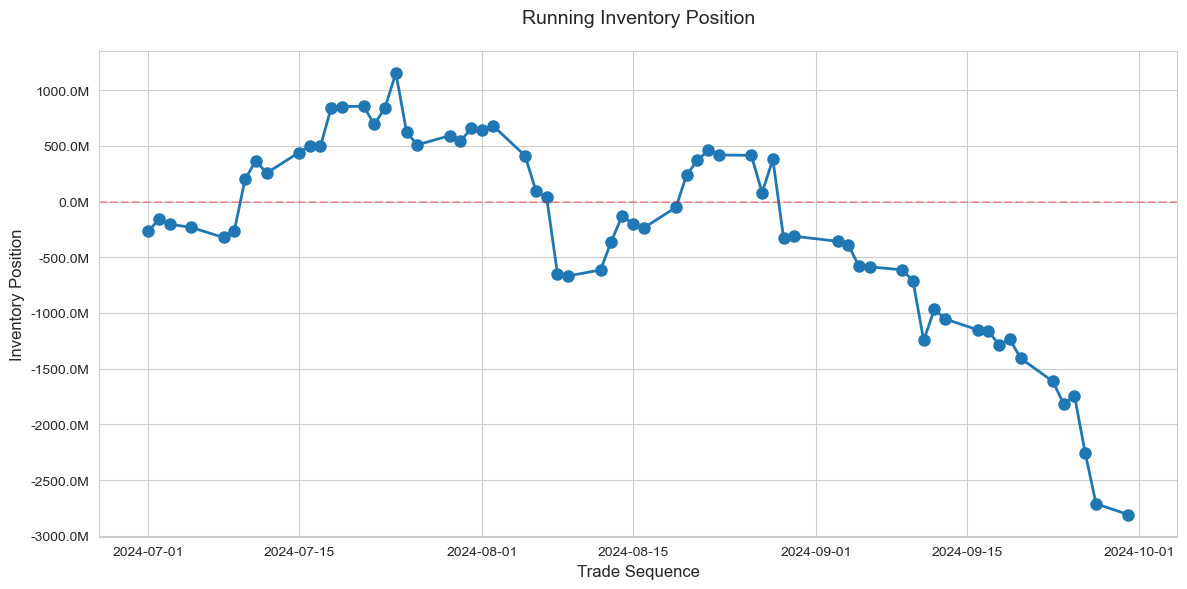

In [ ]:
plt.figure(figsize=(12, 6))
sns.set_style("whitegrid")

# Plot running inventory
plt.plot(inventory1.Date, inventory1['End of Day Inventory'], 
         marker='o', linewidth=2, markersize=8)

# Customize the plot
plt.title('Running Inventory Position', fontsize=14, pad=20)
plt.ylabel('Inventory Position', fontsize=12)
plt.xlabel('Trade Sequence', fontsize=12)

# Add horizontal line at y=0
plt.axhline(y=0, color='r', linestyle='--', alpha=0.3)

# Format y-axis labels to millions
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{x/1e6:.1f}M'))

plt.tight_layout()
plt.show()

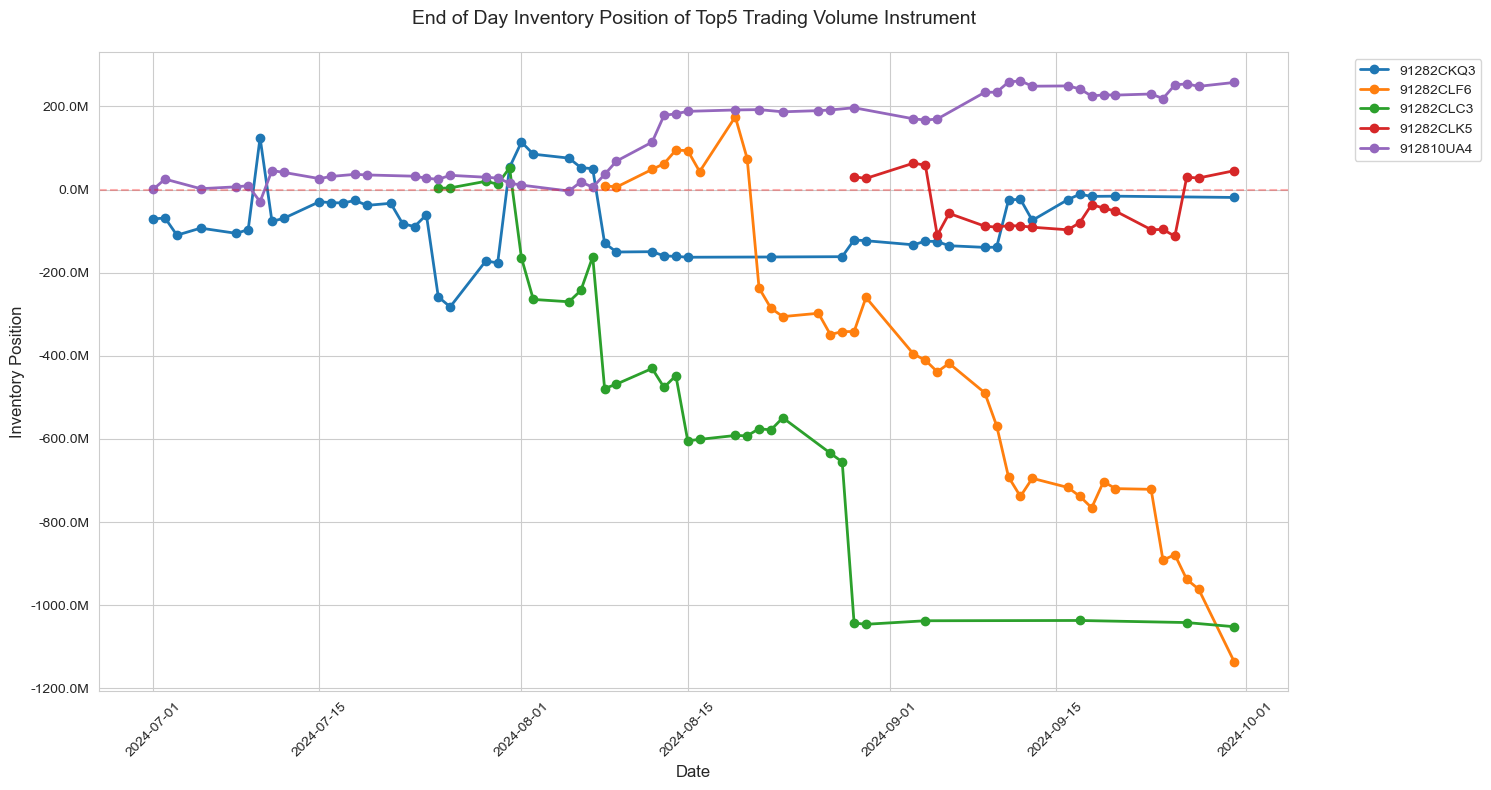

In [86]:
top5_code = ['91282CKQ3','91282CLF6','91282CLC3','91282CLK5','912810UA4']
all_instruments_data = []

for i in top5_code:
   top5_data = df[df['InstrumentCode'] == i].copy()
   if not top5_data.empty:  # Only process if we have data for this instrument
       daily_inv = calculate_daily_inventory(top5_data)
       daily_inv['Instrument'] = i
       all_instruments_data.append(daily_inv)

top5_df = pd.concat(all_instruments_data, ignore_index=True)

plt.figure(figsize=(15, 8))
sns.set_style("whitegrid")
for i in top5_code:
   top5_data = top5_df[top5_df['Instrument'] == i]
   if not top5_data.empty:
       plt.plot(top5_data['Date'], 
               top5_data['End of Day Inventory'],
               marker='o',
               label=i,
               linewidth=2,
               markersize=6)

plt.title('End of Day Inventory Position of Top5 Trading Volume Instrument', fontsize=14, pad=20)
plt.ylabel('Inventory Position', fontsize=12)
plt.xlabel('Date', fontsize=12)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

# Format y-axis labels to millions
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{x/1e6:.1f}M'))

# Rotate x-axis labels for better readability
plt.xticks(rotation=45)

# Add horizontal line at y=0
plt.axhline(y=0, color='r', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()